# Import ibt files

In [1]:

import pandas as pd
import irsdk
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np

# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
ibt_file = root_path + "data/formulavee_charlotte 2025 roval2025 2026-01-22 09-33-17.ibt"

# --- Configuration ---
IBT_FILES = [
    Path(ibt_file)
]

USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = ['SessionTime','Lap','Speed','RPM',
                    'LapDistPct','SteeringWheelAngle',
                    'LatAccel','LongAccel','Lat','Lon']
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)

df_coords = load_from_ibt(Path(ibt_file))

In [2]:
# --- 2. FUNÇÃO PARA FORMATAR MM:SS:ms ---
def format_lap_time(seconds):
    if seconds <= 0:
        return "00:00:000"
    minutes = int(seconds // 60)
    remainder_seconds = seconds % 60
    # {:02d} força 2 dígitos para minutos
    # {:06.3f} força 2 dígitos para segundos + ponto + 3 para milissegundos
    return f"{minutes:02d}:{remainder_seconds:06.3f}".replace('.', ':')

# --- 3. CÁLCULO DOS TEMPOS POR VOLTA ---
# Calculamos o tempo final menos o tempo inicial de cada Lap
lap_summary = df_coords.groupby('Lap')['SessionTime'].agg(['min', 'max'])
lap_summary['Duration_s'] = lap_summary['max'] - lap_summary['min']

# Aplicamos a formatação
lap_summary['Time_Formatted'] = lap_summary['Duration_s'].apply(format_lap_time)

# --- 4. EXIBIÇÃO ---
print("=== Resumo de Voltas ===")
# Removemos a volta 0 se ela for apenas a saída dos boxes (opcional)
lap_summary_filtered = lap_summary[lap_summary.index > 0]

print(lap_summary[['Time_Formatted']])

=== Resumo de Voltas ===
    Time_Formatted
Lap               
0        18:38:900
1        04:34:417
2        01:59:700
3        04:31:383
4        04:28:183
5        00:06:233


# Import Track Files

In [3]:
import pandas as pd
import json

# Carregar Metadados
with open('track_metadata.json', 'r') as f:
    meta = json.load(f)
    LAT_REF = meta['LAT_REF']
    LON_REF = meta['LON_REF']

track_path = "data/charlotte_roval/"
# Carregar Infraestrutura
df_limites_esq = pd.read_csv(f'{root_path + track_path}roval_limite_esq.csv')
df_limites_dir = pd.read_csv(f'{root_path + track_path}roval_limite_dir.csv')
df_centerline = pd.read_csv(f'{root_path + track_path}roval_centerline.csv')

print(f"Circuito {meta['TRACK_NAME']} carregado e pronto para análise.")

Circuito Charlotte Roval carregado e pronto para análise.


## 1. Conversão de Coordenadas para Metros

Como a Terra não é plana, um grau de Latitude não tem o mesmo comprimento de um grau de Longitude. Para Charlotte Motor Speedway ($\approx 35.35^\circ$ N), utilizaremos os seguintes fatores de conversão: 

$1^\circ \text{ de Latitude} \approx 110.940 \text{ metros}$

$1^\circ \text{ de Longitude} \approx 90.795 \text{ metros}$ (ajustado pelo cosseno da latitude local)

In [4]:
# --- CONSTANTES GLOBAIS (Charlotte Motor Speedway) ---
FACTOR_LAT = 110940  # Metros por grau de Latitude
FACTOR_LON = 90795   # Metros por grau de Longitude
ANGLE_LANDSCAPE = 90 # Rotação para modo paisagem

In [5]:
from scipy.interpolate import interp1d

def calculate_n_meters(df_fast, df_centerline):
    # 1. Interpolar a Centerline permitindo pequena extrapolação
    # Isso evita o erro se o LapDistPct for levemente menor que 0 ou maior que 1
    interp_lat = interp1d(df_centerline['LapDistPct'], df_centerline['Lat'], 
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_lon = interp1d(df_centerline['LapDistPct'], df_centerline['Lon'], 
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    
    # Referencial da linha central no espaço do piloto
    lat_c = interp_lat(df_fast['LapDistPct'])
    lon_c = interp_lon(df_fast['LapDistPct'])
    
    # 2. Calcular as diferenças em graus
    d_lat = df_fast['Lat'] - lat_c
    d_lon = df_fast['Lon'] - lon_c
    
    # 3. Converter para metros (Fatores de Charlotte Motor Speedway)
    d_lat_m = d_lat * FACTOR_LAT
    d_lon_m = d_lon * FACTOR_LON
    
    # 4. Calcular a magnitude do desvio lateral (n) em metros
    # O sinal indica se o piloto está à esquerda ou direita da centerline
    n = np.sqrt(d_lat_m**2 + d_lon_m**2) * np.sign(d_lon) 
    
    return n

# --- Execução Corrigida para a Volta 2 ---
df_volta_2 = df_coords[df_coords['Lap'] == 2].copy()
n_meters = calculate_n_meters(df_volta_2, df_centerline)

print(f"Desvio lateral calculado para a Volta 2. Desvio máximo: {np.max(np.abs(n_meters)):.2f} metros.")

Desvio lateral calculado para a Volta 2. Desvio máximo: 9.58 metros.


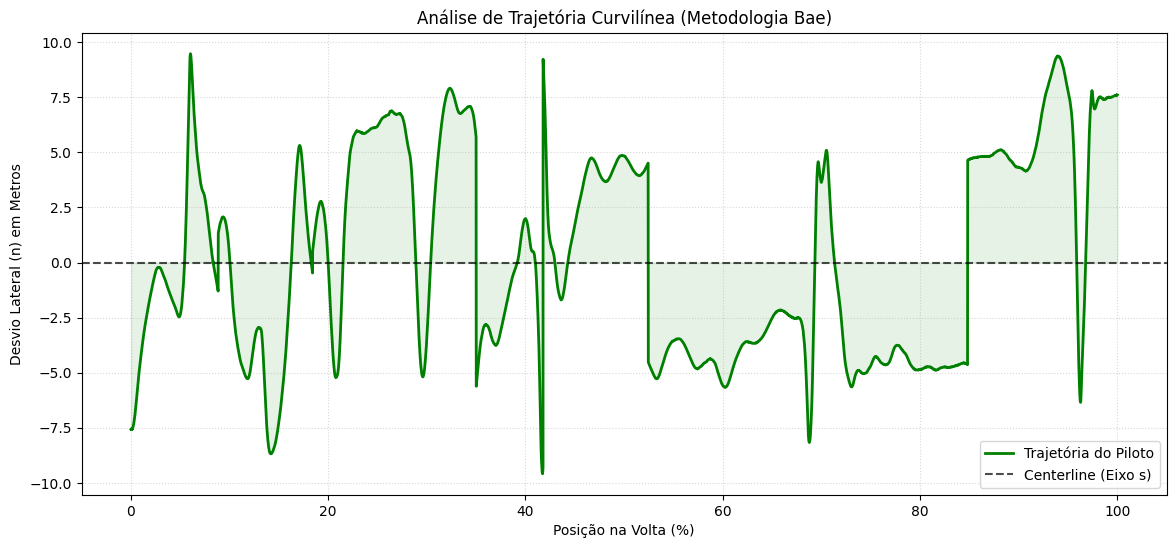

In [6]:
plt.figure(figsize=(14, 6))

# Plotar o desvio lateral
plt.plot(df_volta_2['LapDistPct'] * 100, n_meters, color='green', linewidth=2, label='Trajetória do Piloto')

# Linha Central (Referência Zero)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Centerline (Eixo s)')

# Estética do gráfico
plt.fill_between(df_volta_2['LapDistPct'] * 100, n_meters, color='green', alpha=0.1)
plt.xlabel('Posição na Volta (%)')
plt.ylabel('Desvio Lateral (n) em Metros')
plt.title('Análise de Trajetória Curvilínea (Metodologia Bae)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.show()

## Plot de pista + desvio lateral de posição

Estas funções realizam a "matemática pesada" de forma transparente para o usuário, convertendo as coordenadas GPS em um sistema Cartesiano 
($x, y$) em metros e calculando o desvio $n$.

$$x_m = (\text{Lon} - \text{Lon}_{ref}) \times 90795$$

$$y_m = (\text{Lat} - \text{Lat}_{ref}) \times 110940$$

In [45]:
from ipywidgets import interact, widgets

def preparar_geometria(df, angle=ANGLE_LANDSCAPE):
    """Converte Lat/Lon para Metros Rotacionados."""
    y_m = (df['Lat'] - LAT_REF) * FACTOR_LAT
    x_m = (df['Lon'] - LON_REF) * FACTOR_LON
    
    angle_rad = np.radians(angle)
    x_rot = x_m * np.cos(angle_rad) - y_m * np.sin(angle_rad)
    y_rot = x_m * np.sin(angle_rad) + y_m * np.cos(angle_rad)
    return x_rot, y_rot

def calcular_n_bae(df_fast, df_center):
    """Calcula o desvio lateral n em metros com correção de limites."""
    interp_lat = interp1d(df_center['LapDistPct'], df_center['Lat'], 
                          bounds_error=False, fill_value="extrapolate")
    interp_lon = interp1d(df_center['LapDistPct'], df_center['Lon'], 
                          bounds_error=False, fill_value="extrapolate")
    
    d_lat_m = (df_fast['Lat'] - interp_lat(df_fast['LapDistPct'])) * FACTOR_LAT
    d_lon_m = (df_fast['Lon'] - interp_lon(df_fast['LapDistPct'])) * FACTOR_LON
    
    return np.sqrt(d_lat_m**2 + d_lon_m**2) * np.sign(d_lon_m)

def analise_dinamica_bae(df_volta_alvo):
    # Processamento Interno Automático
    n_series = calcular_n_bae(df_volta_alvo, df_centerline)
    x_v, y_v = preparar_geometria(df_volta_alvo)
    x_c, y_c = preparar_geometria(df_centerline)
    x_le, y_le = preparar_geometria(df_limites_esq)
    x_ld, y_ld = preparar_geometria(df_limites_dir)
    

    def plot_frame(index=2):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 2]})
        
        # Ponto atual (usando .iloc para evitar KeyError)
        curr_pct = df_volta_alvo['LapDistPct'].iloc[index] * 100
        curr_n = n_series.iloc[index]
        
        # Plot 1: Desvio Lateral n (Metas: Estabilidade e Trajetória)
        ax1.plot(df_volta_alvo['LapDistPct'] * 100, n_series, color='blue', alpha=0.4)
        ax1.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax1.scatter(curr_pct, curr_n, color='red', s=50, zorder=5)
        ax1.set_title(f"Análise Bae: Volta Selecionada | Estação s={curr_pct:.1f}% | Desvio n={curr_n:.2f}m")
        ax1.set_ylabel("Desvio n (Metros)")
        ax1.grid(True, alpha=0.2)

        # Plot 2: Mapa Landscape (Fronteiras e Posição Real)
        ax2.plot(x_le, y_le, 'gray', alpha=0.2)
        ax2.plot(x_ld, y_ld, 'gray', alpha=0.2)
        ax2.plot(x_c, y_c, 'k--', alpha=0.1)
        ax2.plot(x_v, y_v, color='blue', alpha=0.3)
        ax2.scatter(x_v.iloc[index], y_v.iloc[index], color='red', s=80, edgecolors='black')
        
        ax2.set_aspect('equal')
        ax2.set_xlabel("X (Metros)")
        ax2.set_ylabel("Y (Metros)")
        plt.tight_layout()
        plt.show()
        plt.close()   
        
    interact(plot_frame, index=widgets.IntSlider(min=0, max=len(df_volta_alvo)-1, step=1, value=0, description='Posição:'))
    
    
    

# --- COMO USAR ---
analise_dinamica_bae(df_volta_2)


interactive(children=(IntSlider(value=0, description='Posição:', max=7182), Output()), _dom_classes=('widget-i…

# Testando com o OpenStreetMap



In [ ]:
%pip install osmnx


In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Configuração de busca focada no centro da pista
# Coordenadas aproximadas do centro da tri-oval
center_point = (35.3515, -80.6827)
tags = {"highway": "raceway"}

# 2. Download dos dados
# Reduzi o raio para 800m para evitar pegar o Dragway mesmo sem filtros
track_features = ox.features_from_point(center_point, tags=tags, dist=800)
all_lines = track_features[track_features.geometry.type == 'LineString'].copy()

# 3. MÁSCARA DE FILTRAGEM AMPLIADA
# Incluímos '1/4' para pegar a reta que você identificou
# Incluímos qualquer variação de 'Charlotte Motor Speedway'
include_mask = all_lines['name'].str.contains('Roval|1/4|Charlotte Motor Speedway', na=False, case=False)

# Mantemos a exclusão de pistas de terra ou kart que fiquem no raio
exclude_mask = all_lines['name'].str.contains('Dirt|Kart', na=False, case=False)

roval_final = all_lines[include_mask & ~exclude_mask]

# 4. Plotagem com Verificação de Nomes
fig, ax = plt.subplots(figsize=(12, 12))

# Plotamos o que sobrou (o traçado completo)
roval_final.plot(ax=ax, color='red', linewidth=3, label='Traçado Roval Completo')

# Adicionamos os nomes nos segmentos para você conferir se falta algo
for x, y, label in zip(roval_final.geometry.centroid.x, roval_final.geometry.centroid.y, roval_final['name']):
    ax.text(x, y, label, fontsize=8, alpha=0.7)

plt.title("Charlotte Roval: Circuito Fechado (OSM)")
plt.axis('equal')
plt.grid(True, alpha=0.2)
plt.show()

# 5. Lista de nomes incluídos (para seu controle de dados)
print("Segmentos incluídos no banco de dados:")
print(roval_final['name'].unique())

In [ ]:
# Extrair todos os pontos (nós) do traçado filtrado para uma lista de coordenadas
coords_list = []
for line in roval_final.geometry:
    coords_list.extend(list(line.coords))

# Criar um DataFrame de referência para sua investigação
df_osm_reference = pd.DataFrame(coords_list, columns=['Lon', 'Lat'])
print(f"Banco de dados de referência criado com {len(df_osm_reference)} pontos.")

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# Em vez de extrair os pontos para uma lista, plote diretamente do GeoDataFrame
# Isso mantém as conexões apenas dentro de cada segmento original
for geom in roval_final.geometry:
    x, y = geom.xy
    ax.plot(x, y, color='blue', linewidth=2)

# Adicionar os pontos (opcional, para ver a densidade de dados)
# ax.scatter(df_osm_reference['Lon'], df_osm_reference['Lat'], color='red', s=5, alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Charlotte Roval - Referência OSM Corrigida')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()